# Pronóstico del precio de Tesla con Series de Tiempo Difusas (Fuzzy Time Series)

**Materia:** Inteligencia Computacional — UPTC

**Integrantes:** Andrés Santiago Daza Quintana, Óscar Alejandro Roa Donzel

**Dataset:** Tesla Stock Price History (Kaggle) — columnas Date, Open, High, Low, Close, Adj Close, Volume.

**Objetivo hipotético:** pronosticar el precio de cierre ajustado (Adj Close) de la acción de Tesla para el día siguiente, a partir de su comportamiento histórico reciente.

**Algoritmo de inteligencia computacional:** Series de Tiempo Difusas (Fuzzy Time Series), basado en Song & Chissom (1993) y Chen (1996). El modelo se implementa "a mano", sin librerías especializadas de FTS.

In [1]:
# Importamos las librerías que vamos a usar en todo el ejercicio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## 1. Carga de datos

In [2]:
# 1. Carga de datos

# Leemos el archivo CSV de Tesla (la columna 0 del archivo es un índice que no necesitamos)
df = pd.read_csv('TESLA.csv', index_col=0)

# Convertimos la columna Date a formato de fecha (el archivo viene en formato mes/dia/año)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')

# Ordenamos cronológicamente por si el archivo no viene ordenado
df = df.sort_values('Date').reset_index(drop=True)

# Nos quedamos solo con la fecha y el precio de cierre ajustado (nuestra serie objetivo)
serie = df[['Date', 'Adj Close']].copy()

print("Cantidad de registros:", len(serie))
print(serie.head())
print(serie.tail())

Cantidad de registros: 3637
        Date  Adj Close
0 2010-06-29   1.592667
1 2010-06-30   1.588667
2 2010-07-01   1.464000
3 2010-07-02   1.280000
4 2010-07-06   1.074000
           Date   Adj Close
3632 2024-12-03  351.420013
3633 2024-12-04  357.929993
3634 2024-12-05  369.489990
3635 2024-12-06  389.220001
3636 2024-12-09  389.790008


## 2. Análisis exploratorio de la serie de tiempo

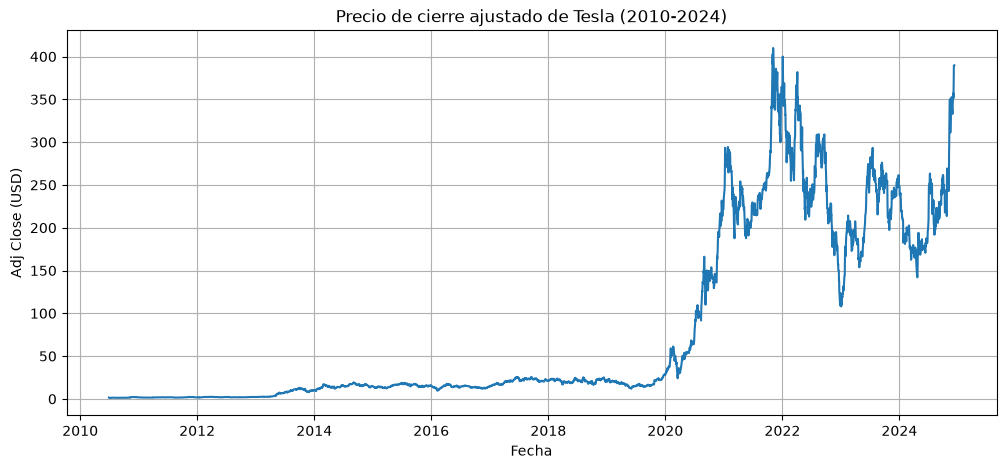

In [3]:
# 2.1 Graficamos la serie completa del precio de cierre ajustado
plt.figure(figsize=(12, 5))
plt.plot(serie['Date'], serie['Adj Close'])
plt.title('Precio de cierre ajustado de Tesla (2010-2024)')
plt.xlabel('Fecha')
plt.ylabel('Adj Close (USD)')
plt.grid(True)
plt.show()

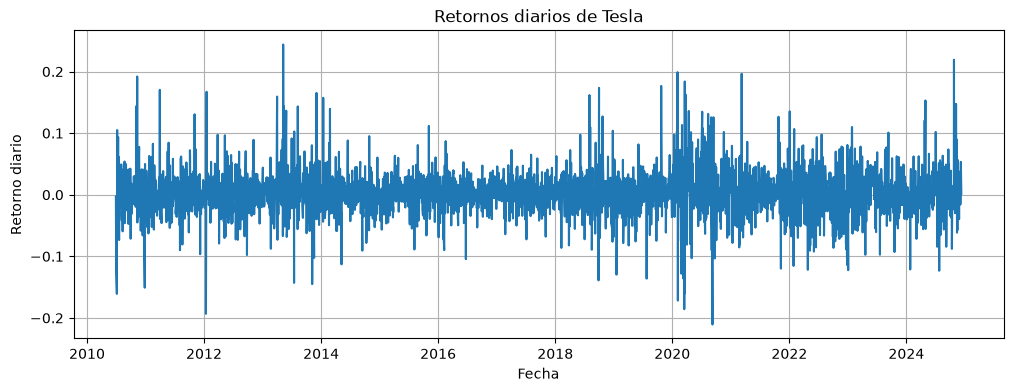

In [4]:
# 2.2 Calculamos los retornos diarios (variación porcentual día a día)
serie['Retorno'] = serie['Adj Close'].pct_change()

# Graficamos los retornos diarios
plt.figure(figsize=(12, 4))
plt.plot(serie['Date'], serie['Retorno'])
plt.title('Retornos diarios de Tesla')
plt.xlabel('Fecha')
plt.ylabel('Retorno diario')
plt.grid(True)
plt.show()

In [5]:
# 2.3 Prueba de estacionariedad de Dickey-Fuller (ADF) sobre el precio en niveles
resultado_adf = adfuller(serie['Adj Close'])

print("Estadístico ADF:", resultado_adf[0])
print("p-valor:", resultado_adf[1])

if resultado_adf[1] < 0.05:
    print("Con un 95% de confianza, la serie es estacionaria")
else:
    print("Con un 95% de confianza, la serie NO es estacionaria (tiene tendencia)")

Estadístico ADF: -0.14443766126985594
p-valor: 0.9448285236295074
Con un 95% de confianza, la serie NO es estacionaria (tiene tendencia)


/tmp/ipykernel_1879/2327131997.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf = adfuller(serie['Adj Close'])


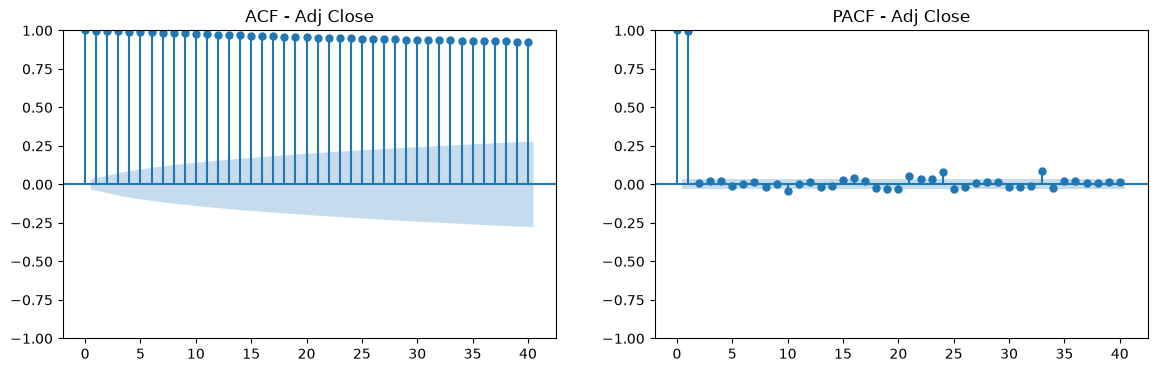

In [6]:
# 2.4 Graficamos la autocorrelación (ACF) y la autocorrelación parcial (PACF)
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie['Adj Close'], lags=40, ax=ejes[0])
ejes[0].set_title('ACF - Adj Close')
plot_pacf(serie['Adj Close'], lags=40, ax=ejes[1])
ejes[1].set_title('PACF - Adj Close')
plt.show()

# Nota: la ACF decae muy lentamente (no llega rápido a cero), lo cual es típico de series
# no estacionarias con tendencia, y coincide con el resultado de la prueba de Dickey-Fuller.

## 3. Partición cronológica en entrenamiento, validación y prueba

In [7]:
# 3. Partición cronológica (NO aleatoria, NO estratificada)
# Requisito de la materia: 80% entrenamiento, 10% validación y 10% prueba,
# respetando siempre el orden temporal (train = más antiguo, test = más reciente).

n = len(serie)
porcentaje_train = 0.80
porcentaje_val = 0.10
# El porcentaje de test queda implícito (0.10) para no perder registros por redondeo

n_train = int(n * porcentaje_train)
n_val = int(n * porcentaje_val)
n_test = n - n_train - n_val   # así garantizamos que train + val + test = n exactamente

# Índices de corte (en términos de la serie completa, ya ordenada cronológicamente)
corte_train_val = n_train             # fin de train / inicio de validación
corte_val_test = n_train + n_val      # fin de validación / inicio de test

train = serie.iloc[:corte_train_val].reset_index(drop=True)
validacion = serie.iloc[corte_train_val:corte_val_test].reset_index(drop=True)
test = serie.iloc[corte_val_test:].reset_index(drop=True)

print("Registros de entrenamiento:", len(train), "(%.1f%%)" % (100 * len(train) / n),
      "->", train['Date'].min().date(), "a", train['Date'].max().date())
print("Registros de validación:  ", len(validacion), "(%.1f%%)" % (100 * len(validacion) / n),
      "->", validacion['Date'].min().date(), "a", validacion['Date'].max().date())
print("Registros de prueba:      ", len(test), "(%.1f%%)" % (100 * len(test) / n),
      "->", test['Date'].min().date(), "a", test['Date'].max().date())
print("\nTotal train + validación + prueba:", len(train) + len(validacion) + len(test), "de", n, "registros")

Registros de entrenamiento: 2909 (80.0%) -> 2010-06-29 a 2022-01-14
Registros de validación:   363 (10.0%) -> 2022-01-18 a 2023-06-28
Registros de prueba:       365 (10.0%) -> 2023-06-29 a 2024-12-09

Total train + validación + prueba: 3637 de 3637 registros


## 4. Modelo baseline: naive forecast y regresión lineal simple

In [8]:
# Para que la comparación entre modelos sea justa, todos van a pronosticar el precio de "hoy"
# usando únicamente el precio real de "ayer" (pronóstico a un paso hacia adelante).
# Construimos estos pares (ayer -> hoy) tanto para validación (para elegir hiperparámetros)
# como para test (para la evaluación final, que nadie usó todavía).

valores_completos = serie['Adj Close'].values

# --- Conjunto de validación ---
# valor_anterior_val[i] es el precio real del día justo anterior a validacion.iloc[i]
valor_anterior_val = valores_completos[corte_train_val - 1 : corte_val_test - 1]
# valor_real_val[i] es el precio real que queremos pronosticar en validación
valor_real_val = valores_completos[corte_train_val : corte_val_test]

# --- Conjunto de prueba (test) ---
# valor_anterior_test[i] es el precio real del día justo anterior a test.iloc[i]
valor_anterior_test = valores_completos[corte_val_test - 1 : n - 1]
# valor_real_test[i] es el precio real que queremos pronosticar en test
valor_real_test = valores_completos[corte_val_test : n]

print("Pares (ayer, hoy) en validación:", len(valor_anterior_val))
print("Pares (ayer, hoy) en test:      ", len(valor_anterior_test))

Pares (ayer, hoy) en validación: 363
Pares (ayer, hoy) en test:       365


In [9]:
# 4.1 Baseline naive: el pronóstico de mañana es igual al precio de hoy
# (no tiene hiperparámetros, así que se evalúa directamente sobre el test)
pronostico_naive = valor_anterior_test.copy()

In [10]:
# 4.2 Baseline de regresión lineal simple: precio_hoy = pendiente * precio_ayer + intercepto
# La ajustamos SOLO con los datos de entrenamiento (tampoco tiene hiperparámetros que ajustar
# con validación, así que se evalúa directamente sobre el test)
x_train = train['Adj Close'].values[:-1]   # precio de "ayer"
y_train = train['Adj Close'].values[1:]    # precio de "hoy"

pendiente, intercepto = np.polyfit(x_train, y_train, 1)
print("Pendiente:", pendiente, "- Intercepto:", intercepto)

pronostico_regresion = pendiente * valor_anterior_test + intercepto

Pendiente: 1.0016914159498227 - Intercepto: 0.048531273593004666


### 4.3 Funciones de error (MAE, RMSE, MAPE)

Las definimos ya en esta sección porque las vamos a usar dos veces: primero sobre el conjunto de
**validación**, para elegir el número de intervalos del modelo FTS, y después sobre el conjunto de
**prueba**, para la evaluación final y comparación entre los tres modelos.

In [11]:
def calcular_mae(real, pronostico):
    return np.mean(np.abs(real - pronostico))

def calcular_rmse(real, pronostico):
    return np.sqrt(np.mean((real - pronostico) ** 2))

def calcular_mape(real, pronostico):
    return np.mean(np.abs((real - pronostico) / real)) * 100

## 5. Modelo de Series de Tiempo Difusas (Fuzzy Time Series)

Seguimos, de forma simplificada, los pasos clásicos de Song & Chissom (1993) y Chen (1996):

1. Definir el universo del discurso a partir del train.
2. Partir el universo en intervalos y asociar un conjunto difuso a cada intervalo.
3. Fuzzificar la serie (asignar cada precio a su intervalo).
4. Generar las relaciones lógicas difusas (FLR): A_i -> A_j.
5. Agrupar las FLR en grupos (FLRG).
6. Usar los FLRG para pronosticar (desfuzzificar con el punto medio de los intervalos).

El único hiperparámetro del modelo es la cantidad de intervalos (`n_intervalos`) en que se divide el
universo del discurso. En vez de fijarlo arbitrariamente, lo seleccionamos probando varios valores
candidatos y quedándonos con el que mejor generaliza sobre el conjunto de **validación** (datos que el
modelo nunca usa para construirse). El conjunto de **test** queda completamente reservado para la
evaluación final, igual que en los baselines.

In [12]:
# 5.1 - 5.5: empaquetamos los pasos 1 a 5 (universo, fuzzificación, FLR y FLRG) en una función,
# parametrizada por n_intervalos, para poder reconstruir el modelo con distintos valores candidatos
# usando SIEMPRE solo los datos de entrenamiento.

def fuzzificar_valor(valor, U_min, ancho_intervalo, n_intervalos):
    # Paso 3: asigna un precio real al intervalo (conjunto difuso) al que pertenece
    indice = int((valor - U_min) / ancho_intervalo)
    # Si el valor cae justo en el límite superior o se sale un poco del universo, lo recortamos
    if indice < 0:
        indice = 0
    if indice >= n_intervalos:
        indice = n_intervalos - 1
    return indice

def construir_modelo_fts(datos_train, n_intervalos):
    """Construye el universo del discurso, la fuzzificación, las FLR y los FLRG
    a partir de los precios de ENTRENAMIENTO, para un número dado de intervalos."""

    # Paso 1: universo del discurso a partir del train (con un pequeño margen extra)
    margen = (datos_train.max() - datos_train.min()) * 0.05
    U_min = datos_train.min() - margen
    U_max = datos_train.max() + margen

    # Paso 2: partimos el universo en n_intervalos conjuntos difusos A_0, ..., A_{n-1}
    ancho_intervalo = (U_max - U_min) / n_intervalos
    limites = [U_min + i * ancho_intervalo for i in range(n_intervalos + 1)]
    puntos_medios = [(limites[i] + limites[i + 1]) / 2 for i in range(n_intervalos)]

    # Paso 3: fuzzificamos toda la serie de entrenamiento
    etiquetas = [fuzzificar_valor(v, U_min, ancho_intervalo, n_intervalos) for v in datos_train]

    # Paso 4: generamos las FLR comparando la etiqueta de cada día con la del día siguiente
    relaciones = []
    for i in range(len(etiquetas) - 1):
        relaciones.append((etiquetas[i], etiquetas[i + 1]))

    # Paso 5: agrupamos las FLR en FLRG (todas las relaciones que parten del mismo A_i)
    flrg = {}
    for origen, destino in relaciones:
        if origen not in flrg:
            flrg[origen] = []
        if destino not in flrg[origen]:
            flrg[origen].append(destino)

    return {
        'n_intervalos': n_intervalos,
        'U_min': U_min,
        'U_max': U_max,
        'ancho_intervalo': ancho_intervalo,
        'puntos_medios': puntos_medios,
        'etiquetas_train': etiquetas,
        'relaciones': relaciones,
        'flrg': flrg,
    }

# Construimos un modelo ilustrativo con n_intervalos = 10 (el valor que se usaba antes fijo)
# solo para mostrar cómo se ven el universo, las etiquetas y los FLRG.
modelo_ilustrativo = construir_modelo_fts(train['Adj Close'].values, 10)

print("Universo del discurso: [%.2f, %.2f]" % (modelo_ilustrativo['U_min'], modelo_ilustrativo['U_max']))
print("Ancho de cada intervalo: %.2f" % modelo_ilustrativo['ancho_intervalo'])
print("Primeras 10 etiquetas difusas del train:", modelo_ilustrativo['etiquetas_train'][:10])
print("Cantidad de relaciones (FLR) generadas:", len(modelo_ilustrativo['relaciones']))

print("\nGrupos FLRG obtenidos, por ejemplo A_3 -> A_2, A_3, A_4:")
flrg_ilustrativo = modelo_ilustrativo['flrg']
for origen in sorted(flrg_ilustrativo.keys()):
    destinos_texto = ["A_%d" % d for d in flrg_ilustrativo[origen]]
    print("A_%d -> %s" % (origen, destinos_texto))

Universo del discurso: [-19.39, 430.42]
Ancho de cada intervalo: 44.98
Primeras 10 etiquetas difusas del train: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Cantidad de relaciones (FLR) generadas: 2908

Grupos FLRG obtenidos, por ejemplo A_3 -> A_2, A_3, A_4:
A_0 -> ['A_0', 'A_1']
A_1 -> ['A_0', 'A_1', 'A_2']
A_2 -> ['A_2', 'A_3']
A_3 -> ['A_3', 'A_4', 'A_2']
A_4 -> ['A_3', 'A_4', 'A_5']
A_5 -> ['A_5', 'A_4', 'A_6']
A_6 -> ['A_6', 'A_5', 'A_7']
A_7 -> ['A_7', 'A_8']
A_8 -> ['A_7', 'A_8', 'A_9']
A_9 -> ['A_9', 'A_8']


In [13]:
# 5.6 Función de pronóstico del modelo difuso (regla de Chen, 1996)
# Para pronosticar el día t: fuzzificamos el precio real del día t-1 y buscamos su FLRG

def pronosticar_fts(valor_anterior, modelo):
    etiqueta = fuzzificar_valor(valor_anterior, modelo['U_min'], modelo['ancho_intervalo'], modelo['n_intervalos'])
    flrg = modelo['flrg']
    puntos_medios = modelo['puntos_medios']
    if etiqueta in flrg and len(flrg[etiqueta]) > 0:
        # Si el grupo tiene uno o varios destinos, el pronóstico es el promedio de sus puntos medios
        destinos = flrg[etiqueta]
        pronostico = np.mean([puntos_medios[d] for d in destinos])
    else:
        # Si esa etiqueta nunca apareció como origen en el train, usamos el punto medio de su propio intervalo
        pronostico = puntos_medios[etiqueta]
    return pronostico

### 5.7 Selección de `n_intervalos` usando el conjunto de validación

In [14]:
# Probamos varios valores candidatos de n_intervalos. Para cada uno, reconstruimos el modelo
# FTS completo (universo, fuzzificación, FLR y FLRG) usando SOLO el train, y lo evaluamos
# pronosticando un paso adelante sobre el conjunto de VALIDACIÓN (que no participó en la
# construcción del modelo). Nos quedamos con el n_intervalos que da el menor error en validación.

candidatos_n_intervalos = [5, 7, 10, 15, 20]
resultados_validacion = []

for n_int in candidatos_n_intervalos:
    modelo_candidato = construir_modelo_fts(train['Adj Close'].values, n_int)
    pronostico_val = np.array([pronosticar_fts(v, modelo_candidato) for v in valor_anterior_val])
    resultados_validacion.append({
        'n_intervalos': n_int,
        'MAE_validacion': calcular_mae(valor_real_val, pronostico_val),
        'RMSE_validacion': calcular_rmse(valor_real_val, pronostico_val),
        'MAPE_validacion (%)': calcular_mape(valor_real_val, pronostico_val),
    })

tabla_validacion = pd.DataFrame(resultados_validacion)
print("Comparación de candidatos sobre el conjunto de validación:")
print(tabla_validacion)

fila_optima = tabla_validacion.loc[tabla_validacion['MAPE_validacion (%)'].idxmin()]
n_intervalos_optimo = int(fila_optima['n_intervalos'])

print("\nn_intervalos elegido:", n_intervalos_optimo,
      "(MAPE en validación = %.3f%%)" % fila_optima['MAPE_validacion (%)'])

Comparación de candidatos sobre el conjunto de validación:
   n_intervalos  MAE_validacion  RMSE_validacion  MAPE_validacion (%)
0             5       22.126750        26.660939            10.673183
1             7       25.959796        30.963733            12.562464
2            10       15.914521        20.371493             6.819438
3            15       12.779405        15.783102             5.766571
4            20       13.167505        16.426603             5.860440

n_intervalos elegido: 15 (MAPE en validación = 5.767%)


### 5.8 Modelo FTS final, reentrenado con el `n_intervalos` elegido

In [15]:
# Con el n_intervalos ya elegido usando SOLO el conjunto de validación, reconstruimos el
# modelo FTS final (de nuevo, a partir de SOLO el train) y lo evaluamos sobre el conjunto de
# TEST, que hasta ahora no se había tocado para nada.

modelo_fts_final = construir_modelo_fts(train['Adj Close'].values, n_intervalos_optimo)

# 5.9 Aplicamos el pronóstico difuso a todo el conjunto de test
pronostico_fts = np.array([pronosticar_fts(v, modelo_fts_final) for v in valor_anterior_test])

print("Modelo FTS final construido con n_intervalos =", n_intervalos_optimo)

Modelo FTS final construido con n_intervalos = 15


## 6. Evaluación final (sobre el conjunto de prueba)

In [16]:
# 6.1 Calculamos las métricas de los tres modelos sobre el conjunto de TEST y las juntamos en una tabla
# (las funciones calcular_mae/calcular_rmse/calcular_mape ya se definieron en la sección 4.3)
resultados = pd.DataFrame({
    'Modelo': ['Naive', 'Regresión lineal', 'Fuzzy Time Series'],
    'MAE': [
        calcular_mae(valor_real_test, pronostico_naive),
        calcular_mae(valor_real_test, pronostico_regresion),
        calcular_mae(valor_real_test, pronostico_fts),
    ],
    'RMSE': [
        calcular_rmse(valor_real_test, pronostico_naive),
        calcular_rmse(valor_real_test, pronostico_regresion),
        calcular_rmse(valor_real_test, pronostico_fts),
    ],
    'MAPE (%)': [
        calcular_mape(valor_real_test, pronostico_naive),
        calcular_mape(valor_real_test, pronostico_regresion),
        calcular_mape(valor_real_test, pronostico_fts),
    ],
})

print(resultados)

              Modelo        MAE       RMSE  MAPE (%)
0              Naive   5.866055   8.413901  2.558241
1   Regresión lineal   5.870325   8.406649  2.564583
2  Fuzzy Time Series  11.178821  13.606622  5.123614


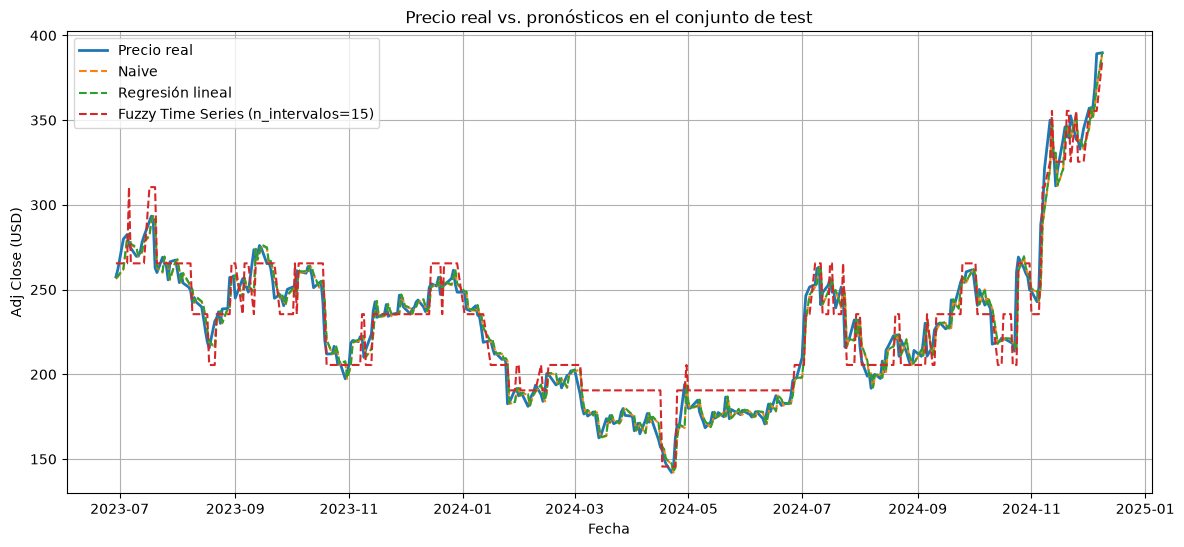

In [17]:
# 6.2 Gráfico comparativo: precio real vs. pronósticos de cada modelo en el conjunto de test
plt.figure(figsize=(14, 6))
plt.plot(test['Date'], valor_real_test, label='Precio real', linewidth=2)
plt.plot(test['Date'], pronostico_naive, label='Naive', linestyle='--')
plt.plot(test['Date'], pronostico_regresion, label='Regresión lineal', linestyle='--')
plt.plot(test['Date'], pronostico_fts, label='Fuzzy Time Series (n_intervalos=%d)' % n_intervalos_optimo, linestyle='--')
plt.title('Precio real vs. pronósticos en el conjunto de test')
plt.xlabel('Fecha')
plt.ylabel('Adj Close (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# 7. Conclusión
#
# Con la partición cronológica 80% train / 10% validación / 10% test, el baseline naive y la
# regresión lineal simple obtienen errores muy similares y bajos (MAPE ~2.56%), porque el precio
# de una acción se comporta casi como un "camino aleatorio": el mejor predictor del precio de
# mañana termina siendo el precio de hoy. El conjunto de validación se usó para elegir el número
# de intervalos del modelo FTS entre {5, 7, 10, 15, 20}; el valor con menor MAPE en validación fue
# n_intervalos=15 (MAPE en validación ~5.77%). Aun con ese ajuste, el modelo de Series de Tiempo
# Difusas obtiene, sobre el test, un error notablemente mayor que los baselines (MAPE ~5.12%), ya
# que al agrupar el precio en un número fijo de intervalos discretos pierde precisión frente al
# comportamiento continuo de la serie, mostrando que en este caso no logra superar a un baseline
# simple.